## Linear Regression - (Supervised Learning)


$\text{This is a simple approach } \bold{which \ assumes} \color{dodgerblue}{\text{ a linear relationship between the features X} \in \R^p \text{ and the label Y }} \in \R$

### General Example

$\text{We will present a general example throughout this topic to understand where and how Linear Regression is helpful}$

$\text{We want to find the price of a house as a function of its size}$ 

$\text{In other words how much does a house cost based on its square footage}$


<center>

| $\text{Size (Square feet)} - X$ | $\text{Price (\$1000s) - Y}$ |
|----------------------------------|------------------------------|
| 1400                             | 245                          |
| 1600                             | 312                          |
| 1700                             | 279                          |
| 1875                             | 308                          |
| 1100                             | 199                          |
| 1550                             | 219                          |
| 2350                             | 405                          |
| 2450                             | 324                          |
| 1425                             | 319                          |
| 1700                             | 255                          |

</center>

$\text{The above table is an example of: } \color{dodgerblue}\bold{Training Data } $

$ \text{Formally: }$  

$$
\large\boxed{\color{dodgerblue} D = \{(x_i, y_i)\}_{i=1}^{n}}
$$

$\text{In our case n = 10}$

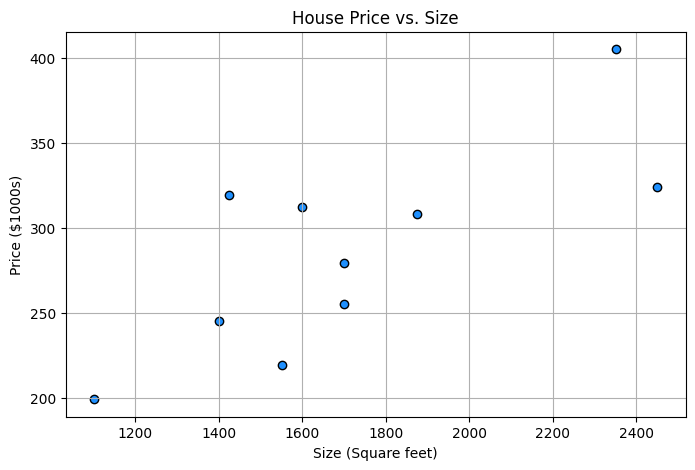

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt

data = {
    "Size (Square feet)": [1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700],
    "Price ($1000s)": [245, 312, 279, 308, 199, 219, 405, 324, 319, 255]
}

df = pd.DataFrame(data)
df 

# Set the figure size
plt.figure(figsize=(8, 5))

# Plot
plt.scatter(df["Size (Square feet)"], df["Price ($1000s)"], color='dodgerblue', edgecolor='black')

# Optional to connect lines  

##plt.plot(df["Size (Square feet)"], df["Price ($1000s)"], color='black', linestyle='--', alpha=0.5)

# Add labels and title
plt.title("House Price vs. Size")
plt.xlabel("Size (Square feet)")
plt.ylabel("Price ($1000s)")

# Grid and display
plt.grid(True)
plt.show()

### Prediction Challenge 

$\text{How can know what the the price of a random house (not necessarily in the Training Data) if we're given its square footage?}$

$ \text{Formally: }$ $$\large \hat{y} = f(x)$$

---


### Approach 1a : Database Matching

- $\text{This method iterates through the lists of house size and searches for a match, } \\ \text{ for each match it will acumalate the price of the house and that match and at the end it will divide by the total number matches there were}$ 
- $\text{Note, we're averaging based on } \bold{matches \ in \ the \ Training \  Data} $

$\color{red} \text{What happens if there are no matches??!}  \\
\text{By this method it seems like our output will be 0 }$

### Approach 1b : K - Nearest Neighbors (KNN)

- $\text{This method recieves an input parameter k, which will search for k houses with smallest changes in house size and output the average price of those houses}$ 
- $\text{This is better than before since we don't have to rely on exact matches to output a result}$
- $\text{This is a general approach and there are different implmentations to this, that are used depending on the dimension size (number of features)}$
- $\text{When there are man features it requires appropriate scaling}$

- Formally: $$\large \hat{y} = \frac{1}{k} = \sum _{i : x_i \in N_k(x)} y_i$$

``` python 
KNN_pseudo(dataset, k, queryPoint):
 for each point in dataset: 
    compute distance to queryPoint

sort distances increasing order

let knn = top k points

     s = sum price of houses in knn 
in output = s / length knn 

```

---


### Approach 2: Curve Fitting

- $\text{Find a function } f_{\theta^*} \text{ that } \bold{best \ fits } \text{the training datase our of a set of functions: }$
$$\large F = \{f_\theta \} _{\theta \in \Omega} $$

- $\text{Using that function w'ell search for the price of the house given the query input}$ 
- $\text{How do we know which family of functions F to use}$


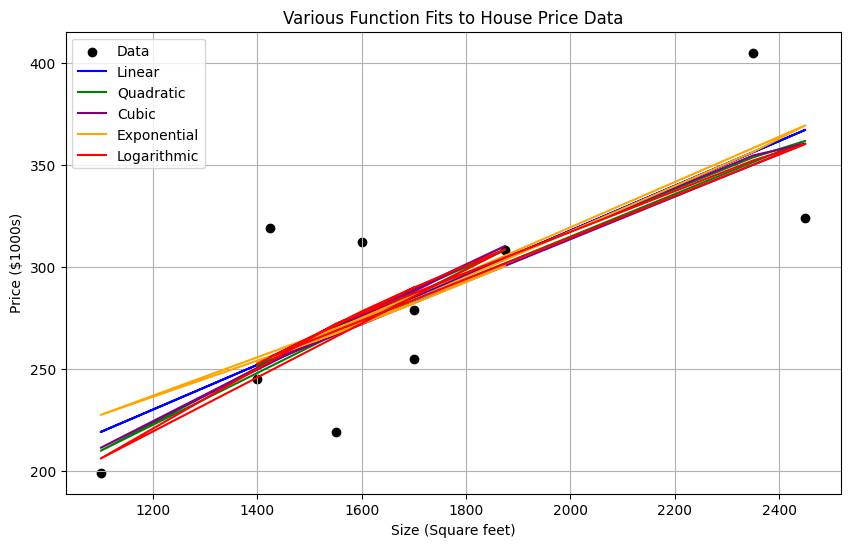

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Data
data = {
    "Size (Square feet)": [1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700],
    "Price ($1000s)": [245, 312, 279, 308, 199, 219, 405, 324, 319, 255]
}

df = pd.DataFrame(data)
X = np.array(df["Size (Square feet)"])
y = np.array(df["Price ($1000s)"])

coeffs_linear = np.polyfit(X, y, deg=1)
y_linear = np.polyval(coeffs_linear, X)

coeffs_quad = np.polyfit(X, y, deg=2)
y_quad = np.polyval(coeffs_quad, X)

coeffs_cubic = np.polyfit(X, y, deg=3)
y_cubic = np.polyval(coeffs_cubic, X)


def exp_func(x, a, b):
    return a * np.exp(b * x)

# Fit to a small subset to avoid overflow
params_exp, _ = curve_fit(exp_func, X / 1000, y, p0=(1, 0.1))  # scaled X to avoid overflow
y_exp = exp_func(X / 1000, *params_exp)

def log_func(x, a, b):
    return a * np.log(x) + b

params_log, _ = curve_fit(log_func, X, y)
y_log = log_func(X, *params_log)


plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data', color='black')

plt.plot(X, y_linear, label='Linear', color='blue')
plt.plot(X, y_quad, label='Quadratic', color='green')
plt.plot(X, y_cubic, label='Cubic', color='purple')
plt.plot(X, y_exp, label='Exponential', color='orange')
plt.plot(X, y_log, label='Logarithmic', color='red')

plt.xlabel("Size (Square feet)")
plt.ylabel("Price ($1000s)")
plt.title("Various Function Fits to House Price Data")
plt.legend()
plt.grid(True)
plt.show()



### Linear Regression 

$\text{Since we're told that the features and the label are linearly related we'll focus on finding the best Linear function out of the family of linear functions F}$

$$
\boxed{F = \{ f_\theta(x) = \theta_0 + \theta_1 x \mid \theta = (\theta_0, \theta_1) \in \mathbb{R}^2 \}}
$$

$\text{We must now narrow down our set of functions to one that } \bold{minimizes \ the \ mosts \ the \ value \ of \ the \ function \ for \ a \ given \ input \ (feature) \ and \ it's \ actual \ label}$

$\text{We'll present the Standard Regression}$

$$ \boxed{J (\theta; D) := \sum^n_{i=1} (f_{\theta}(x_i) - y_i)^2}$$



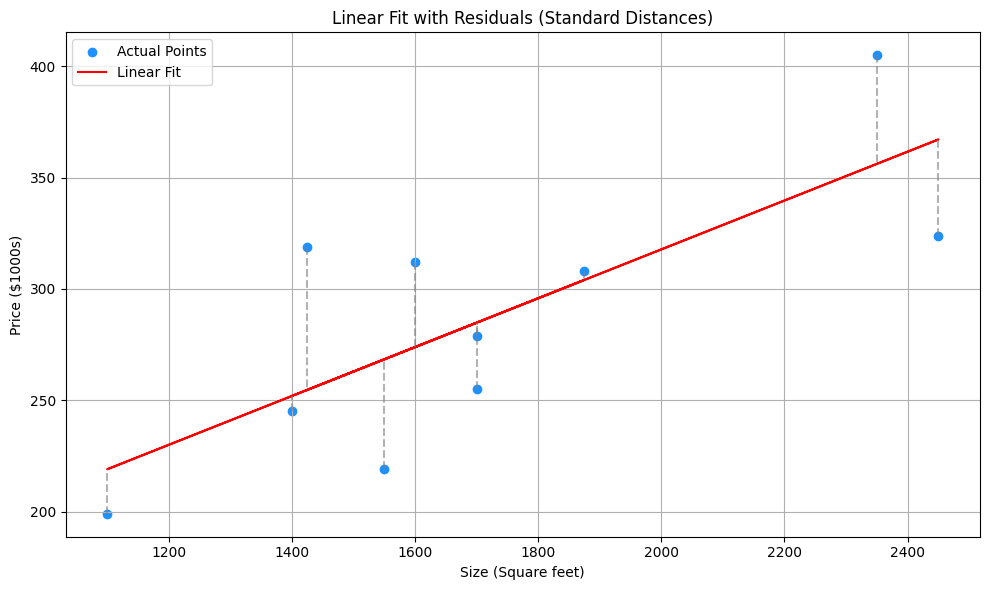

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Define your data
data = {
    "Size (Square feet)": [1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700],
    "Price ($1000s)": [245, 312, 279, 308, 199, 219, 405, 324, 319, 255]
}
df = pd.DataFrame(data)
X = df["Size (Square feet)"].values
y = df["Price ($1000s)"].values

# Step 2: Fit a linear model
coeffs = np.polyfit(X, y, deg=1)
slope, intercept = coeffs
y_pred = np.polyval(coeffs, X)

# Step 3: Plot data + linear line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="dodgerblue", label="Actual Points")
plt.plot(X, y_pred, color="red", label="Linear Fit")

# Step 4: Plot residuals (vertical lines from points to the line)
for xi, yi, yhat in zip(X, y, y_pred):
    plt.plot([xi, xi], [yi, yhat], color="gray", linestyle="--", alpha=0.6)

# Step 5: Labels and show
plt.xlabel("Size (Square feet)")
plt.ylabel("Price ($1000s)")
plt.title("Linear Fit with Residuals (Standard Distances)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



#### Where does the Learning Occur???

$$ \boxed{\large Argmin_{\theta \in \R^2} J(\theta; D) }$$

$\text{We iteratively search for the smallest squared error and then return the function corresponding to this mind results}$

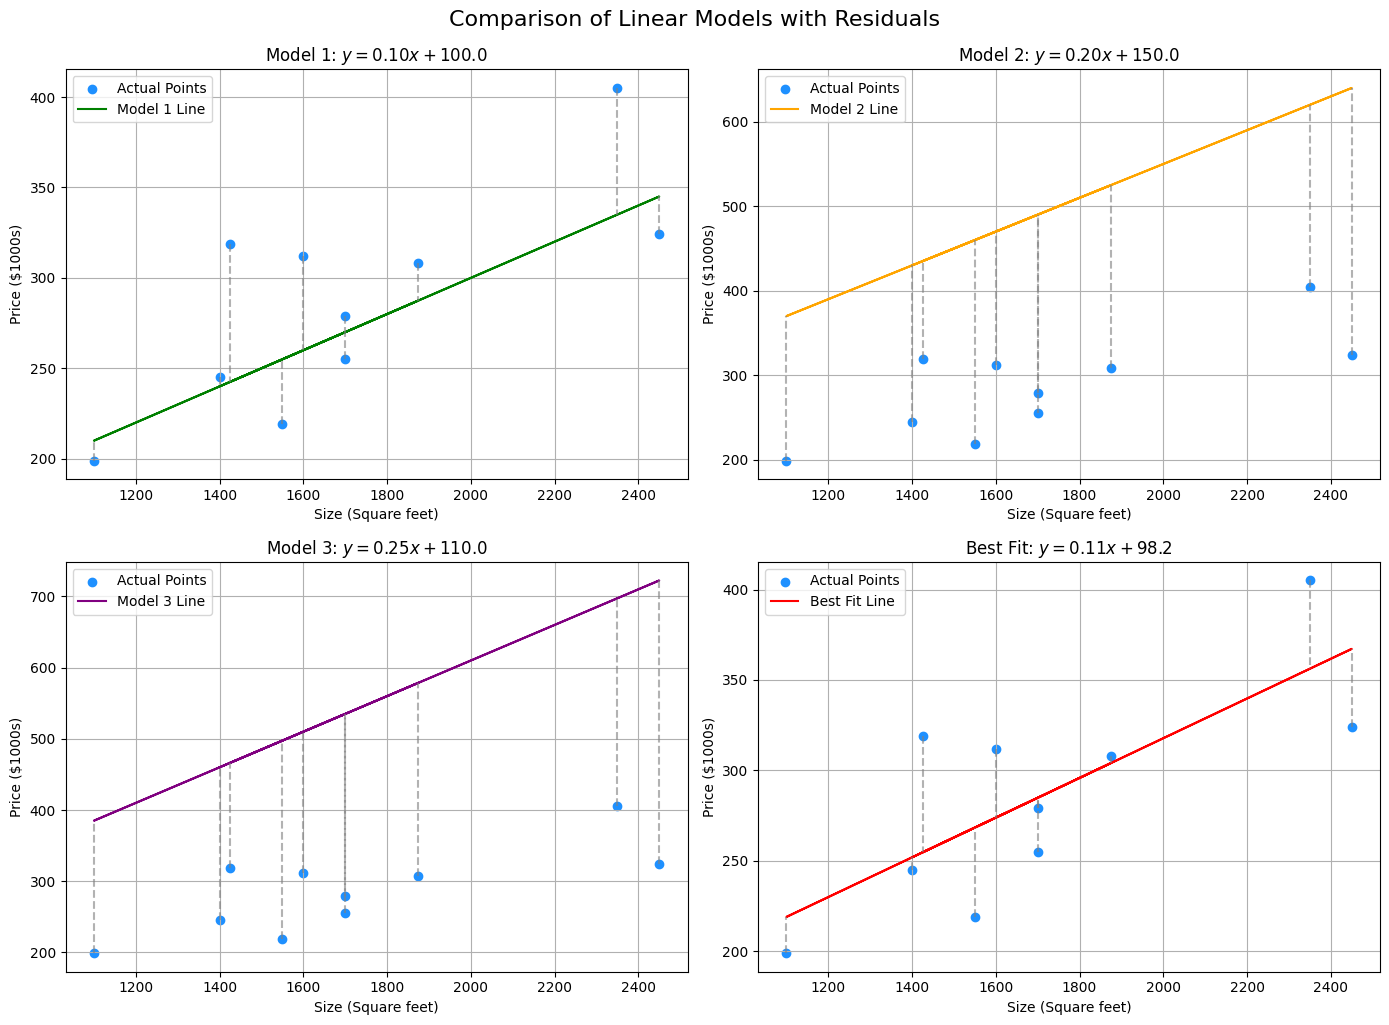

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Define your data
data = {
    "Size (Square feet)": [1400, 1600, 1700, 1875, 1100, 1550, 2350, 2450, 1425, 1700],
    "Price ($1000s)": [245, 312, 279, 308, 199, 219, 405, 324, 319, 255]
}
df = pd.DataFrame(data)
X = df["Size (Square feet)"].values
y = df["Price ($1000s)"].values

# Step 2: Fit the best linear model
best_coeffs = np.polyfit(X, y, deg=1)
slope_best, intercept_best = best_coeffs
y_pred_best = np.polyval(best_coeffs, X)

# Step 3: Try several alternative models
alt_models = [
    {"label": "Model 1", "slope": 0.10, "intercept": 100, "color": "green"},
    {"label": "Model 2", "slope": 0.20, "intercept": 150, "color": "orange"},
    {"label": "Model 3", "slope": 0.25, "intercept": 110, "color": "purple"},
    {"label": "Best Fit", "slope": slope_best, "intercept": intercept_best, "color": "red"}
]

# Step 4: Plot all models with residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, model in enumerate(alt_models):
    ax = axes[i]
    y_model = model["slope"] * X + model["intercept"]
    
    ax.scatter(X, y, color="dodgerblue", label="Actual Points")
    ax.plot(X, y_model, color=model["color"], label=model["label"] + " Line")
    
    # Plot residuals
    for xi, yi, y_hat in zip(X, y, y_model):
        ax.plot([xi, xi], [yi, y_hat], color="gray", linestyle="--", alpha=0.6)
    
    # Annotations
    ax.set_title(f"{model['label']}: $y = {model['slope']:.2f}x + {model['intercept']:.1f}$")
    ax.set_xlabel("Size (Square feet)")
    ax.set_ylabel("Price ($1000s)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Comparison of Linear Models with Residuals", fontsize=16, y=1.02)
plt.show()

###  Multi-Features Linear Regression 

- $\text{Realistically, we'll have multiple features that contribute to a label (we still assume there's a linear relationship)}$ 
- $\text{For example in the price of a house it's likely that it is dependant on: } \{ \text{Size, NumBathrooms, NumBedrooms, YearBuilt, CrimeRate, DistanceToSchool} \}$
- $\text{As such our Linear Regression model changes:}$ $$\large{f_\theta(X) = \theta_0 + \theta_1X_{size} + \theta_2X_{NumBdr} + \theta_3X_{NumBtr} + \theta_4X_{year} + \theta_5X_{rate} + \theta_6X_{dist}}$$ 
- $\text{The above is still linear but just over a higher dimension, so instead of a line we'd be dealing with a plane or some higher dimensional equivelant}$
- $\text{Note: That with more features, we could always investigate combinations of linear regression meaning:} \\ \text{we could reduce to the simple relation between a single feature and the label}$

---

### Linear Regression - Notations 

$\text{We see that linear regression can take place over multiple dimension, as it's dependant on the number of features, so we'll formalise some notation:}$

$$\boxed{ \text{Linear Model:  }  f_{\theta}(X) = \theta_0 + \theta_1X_1 + \theta_2X_2 + ... + \theta_pX_p} $$

$\text{The vector of parameters is what defines the linear function, it's what we adjust in our linear regression algorithm}$ 

$$\boxed{ \theta = ( \theta_0 + \theta_1, \theta_2, ... , \theta_p ) \in \R^{p+1}} $$

$\text{The feature vector of the i-th sample point is denoted as:}$

$$\large x^{(i)} = (x_1^{(i)}, ..., x_p^{(i)})$$

$\text{We have n sample points, and } \bold{EACH \ POINT} \text{ will have p features } \\ \text{ 1. If a certain feature doesn't exist on a sample the it's set to 0.} \\ \text{ 2. Our model has p+1 parameters yet we only have p features starting from } x_1^{(i)} \\ \text{this means that we add a 0th feature evaluated to 1}$

- $\text{If we wanted to find a prediction for some i-th sample point (training or testing):}$

$$\large\boxed{f_{\theta}(x^{(i)})= \sum_{j=0}^p \theta_jx_j^{(i)} = \langle x^{(i)}, \theta \rangle = \theta^Tx^{(i)}}$$


### Least Squared Linear Regression

$\text{Earlier we mentioned how to compute the loss function:}$

$$ \boxed{\left(J (\theta; D) := \sum^n_{i=1} (f_{\theta}(x_i) - y_i)^2\right) \in \R}$$

- $\text{Notice that the squared loss is applied to each sample point where we obtain a single value } \\ \text{we then sum up these values to obtain the overall loss on the entire training dataset}$

- $\text{Our problem Abstracted (Mathematic Point of view only): To find a minimum point from a multi-dimensional function}$

$\text{We have two approaches to solving this:} $
1. $\text{Gradient descent}$
2. $\text{Analytical solution}$

---

## Gradient Descent Algorithm 

1. $\text{Set t=0. Start with an initial "guess" } \theta^{(0)} \in \R^{p+1}$
2. $\text{Compute the gradient } \nabla J(\theta) \text{ at } \theta^{(t)} \text{ with the known formula}$
3. $\text{Update } \theta \text{ in opposite direction of gradient:}$
$$\large \theta^{(t+1)} = \theta^{(t)} - \eta\nabla f(\theta^{(t)})$$
4. $\text{If it hasn't converged (or the loss isn't below some }  \epsilon \text{) then t = t+1 and repeat step 2}$

### Example of the flow of the algorithm 

- $\text{What's given: }$

1. $$J\large(\theta) = \frac{1}{2n} \sum_{i=1}^{n} (h_\theta(x_i) - y_i)^2$$

    - $h_\theta(x) = \theta_0 + \theta_1x \text{ is our linear model.}$

    - $\text{For simplicity, let’s assume } \theta_0 = 0, \text{ so we’re only learning } \theta_1$
2. $\text{Assume that the learning rate } \eta \text{ = 0.1}$

<center>

| $x$ | $y$ | 
|-----|-----|
|   1 |  2  |
|   2 |  4  |
|   3 |  6  |

</center>


##### Gradient Descent Step

1. $\text{We'll minimize}$

$$
J(\theta) = \frac{1}{2n} \sum_{i=1}^{n} \left( \theta_0 + \theta_1 x_i - y_i \right)^2
$$

2. $\text{The gradient}$

\begin{aligned}
\frac{\partial J}{\partial \theta_0} &= \frac{1}{n} \sum_{i=1}^{n} x_0 \left( \theta_0 + \theta_1 x_i - y_i \right) \\
\frac{\partial J}{\partial \theta_1} &= \frac{1}{n} \sum_{i=1}^{n} x_1 \left( \theta_0 + \theta_1 x_i - y_i \right)
\end{aligned}

| $$\text{Iteration}$$ | $$\text{Current Guess}$$ | $$\text{Compute the Gradient}$$ | $$\text{Update}$$ | $$\Delta\text{-change}$$ |
|-----------|--------------|-----------------------|---------|--------|
| 0 | $$\theta_1^{(0)} = 0$$ | $$\nabla J(\theta_1^{(0)}) = \frac{1}{3}[(1)(0 - 2) + (2)(0 - 4) + (3)(0 - 6)] \\ = \frac{1}{3}[-2 - 8 - 18] = \frac{-28}{3} \approx -9.33 $$ | $$\theta_1^{(1)} = \theta_1^{(0)} - 0.1 \cdot (-9.33) \\ = 0 + 0.933 = 0.933$$ | $$+0.933$$ |
| 1 | $$\theta_1^{(1)} = 0.933$$ | $$\nabla J(\theta_1^{(1)}) = \frac{1}{3}[(1)(0.933 - 2) + (2)(1.866 - 4) + (3)(2.799 - 6)] \\= \frac{1}{3}[ -1.067 - 4.268 - 9.201 ] = \frac{-14.536}{3} \approx -4.845$$ | $$\theta_1^{(3)} = 1.4175 + 0.2716 = 1.6891$$| $$+0.4845$$|
| 2 | $$ \theta_1^{(2)} = 1.4175$$ | $$ \nabla J(\theta_1^{(2)}) = \frac{1}{3}[(1)(1.4175 - 2) + (2)(2.835 - 4) + (3)(4.2525 - 6)]=  \\\frac{1}{3}[-0.5825 - 2.33 - 5.235] = \frac{-8.1475}{3} \approx -2.716$$ | $$ \theta_1^{(3)} = 1.4175 + 0.2716 = 1.6891 $$ | $$+0.2716$$ |

---

## Analytical Solution (Closed Form)

$\text{We have a continous a differentiable function and our goal is to find an extreme point; specifically the minimum of the function}$

$\text{This means we need to determine:}$ $$ \nabla J(\theta^*) = 0 $$

$\text{This simplifies to:}$ $$ X^TX\theta = X^Ty$$

$\text{where: }$
$$ \large
\underbrace{
\begin{bmatrix}
x_0^{(1)} & x_0^{(2)} & \cdots & x_0^{(n)} \\
x_1^{(1)} & x_1^{(2)} & \cdots & x_1^{(n)} \\
\vdots & \vdots & \ddots & \vdots \\
x_p^{(1)} & x_p^{(2)} & \cdots & x_p^{(n)}
\end{bmatrix}
}_{X^T}
\begin{bmatrix}
x_0^{(1)} & x_1^{(1)} & \cdots & x_p^{(1)} \\
x_0^{(2)} & x_1^{(2)} & \cdots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
x_0^{(n)} & x_1^{(n)} & \cdots & x_p^{(n)}
\end{bmatrix}
\begin{bmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
x_0^{(1)} & x_1^{(1)} & \cdots & x_p^{(1)} \\
x_0^{(2)} & x_1^{(2)} & \cdots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
x_0^{(n)} & x_1^{(n)} & \cdots & x_p^{(n)}
\end{bmatrix}
}_{X^T}
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

$\text{X - is the Data Matrix; containing of the data points with the p+1 features and the the bias feature}$

$\text{If } X^TX \text{ is invertible then } \theta^* = X^+y \ ( X^+ = (X^TX)^{-1}X^T \text{is known as the pseudo-inverse-matrix)} \text{ is the only point in } \R^{p+1} \text{ where }  \nabla J(\theta) = 0$

$\text{A necesssary condition for invertibility here is that, } n > p + 1 \text{ more sample points than features}$

---

### Gradient Descent vs. Analytical Solution 

| $$\textbf{Gradient Descent}$$ | $$\textbf{Analytical Solution}$$ |
|-----------------------------|----------------------------------|
| $\text{We can apply different loss-functions (Not just the squared error)}$ | $\text{Typically only works with squared error loss}$ |
| $ X^{\top}X \text{doesn't have to be invertible to arrive at a solution}$  | $\text{Requires matrix inversion or pseudo-inverse (may fail if } X^{\top}X  \text{ is singular )}$ |
| $\text{It's more efficient: } O(np) \text{per step}$ | $\text{Higher complexity: } O(np^2 + p^3) $|
| $\text{When } X^{\top}X \text{ is invertible then it will converge}$ | $\text{The pseudo-inverse method provides an exact solution in closed-form}$ |
| $\text{Easy to scale to large datasets or online learning}$ | $\text{Best for small to medium datasets where closed-form computation is feasible}$ |
| $\text{Flexible and customizable (batch, stochastic, mini-batch)}$ | $\text{Rigid structure, no iterative refinement}$ |

---


## Correlation Analysis 

$\text{In data that are related linearly (to some degree) then we can extract and interprete these relations using the Pearsons's Correlation Coefficient}$

$\text{This is almost identical to the correlation coefficient in probability}$

$$ \large \rho := \frac{\sum^n_{i=1}(x_i - \bar{x})y_i - \bar{y}}{\sqrt{\sum^n_{i=1}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^n(y_i - \bar{y})^2}} $$

<center>

<img src="Screenshot 2025-07-23 at 12.10.31.png" alt="screenshot" width="850"/>



## Some correlation Coefficient that aren't captured by Pearsons Correlation

<center>

<img src="Screenshot 2025-07-23 at 12.11.47.png" alt="screenshot" width="850"/>

---

##  Gradient Descent Considerations

### Choosing Eta - $\eta$ 
| $$\text{Case}$$ | $$\text{Effect}$$  | $$\text{Visual}$$ |
|----|-------------| -------------|
|$$\text{Too Small}$$| It'll take many iterations until wit converges | <img src="Screenshot 2025-07-23 at 12.25.38.png" alt="screenshot" width="300"/> |
| $$\text{Too Large}$$ | It may converge to quickly and skip the the extreme point of convergence|  <img src="Screenshot 2025-07-23 at 12.25.44.png" alt="screenshot" width="300"/>| 

- $\text{The graph below shows the learning rate - } \eta \text{ and how it effects the process of the gradient descent}$

<img src="Screenshot 2025-07-23 at 12.39.12.png" alt="screenshot" width="850"/>


### Batch (Using all data) Gradient Descent 

| Problem  | Description | 
| ------- | -------------| 
| 🐢 Slow updates | For large datasets, each update requires scanning the full data <br> (complexity $O(np)$ per step), making it very slow to respond to new information. |
| 🧠 Memory intensive | Must hold all data in memory to compute full gradients — not feasible for big datasets. |
| 🏔️ Can get stuck | Because it’s deterministic and smooth, <br> it may get stuck in local minima or saddle points without noise to escape.|
| ⚖️ Poor scalability | Doesn’t parallelize well for large-scale or online learning applications. |
| 🧾 Delayed learning | Doesn’t start improving the model until it has seen all data once per step <br> not ideal for real-time or streaming data. |

#### Solution : Stochastic Gradient Descent

$\color{dodgerblue}\text{Picks a random instance in the training set at every
step and computes the gradients based only on that single instance}$

#### Mini-Batch Gradient Descent Algorithm 

$\text{Inputs: D - Training Data, } \eta - \text{Learning Rate, } \epsilon \text{-convergence threshold }, \color{dodgerblue}\text{Size of batch}$

1. $\text{Start with initial "guess" } \theta \in \R^{d+1}$
2. $\text{Set t = 0 (this refers to the level of the iteration)}$
3. $\text{While the MSE } > \epsilon \text{ do}$
    - $\color{dodgerblue}\text{Randomly select a set of instances B}$
    - $\text{Compute the gradient } \nabla J (\theta) \text{ at } \theta_t \color{dodgerblue}\text{ with respect to B}$
    - $\text{Move to new point in opposite direction of gradient: } \large\boxed{\theta_{t+1} = \theta_t - \eta\nabla f(\theta_t)}$
    - $\text{Compute the MSE loss between predictions and actual values } \boxed{\text{MSE} = \frac{1}{n} \sum_{i=1}^n \left( \hat{y}_i - y_i \right)^2 \mid \hat{y}_i = f_{\theta}(x^{(i)})= \theta^{\top}x^{(i)}}$

---

## Implementation and Optimisation considerations 

### Normalisation 
- $\text{As the number of features grows, calculating gradients gets computationally expensive.} \\ \text{We can speed this by up normalizing the input data to ensure all values are withing the same range} \\ \text{This becomes more useful and more crtitical with features with high standard deviations or differences in range of the attributes}$
- $\text{We must be careful since sometimes the wide ranges of values are useful, thus normalising could remove this information from the data-set}$

- $\text{The Standartization transformations are: }$
$$
x'_i = \frac{x_i - \bar{x}}{\sigma},\qquad \bar{x} = \frac{1}{n} \sum_{i=1}^n x_i, \quad \sigma = \sqrt{\frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2}
$$
$\text{(here } x = (x_1, x_2, \dots, x_n) \text{ is a sequence of values)}$

---

### Tuning the Learning Rate

- $\text{We mentioned earlier what happens if our learning rate has been "well chosen"} \\ \text{In reality we have to test out a range of values for } \eta \text{ which will allow to chose the best learning rate}$

- $\text{Note this is a convex optimization problem the learning rate will only change the speed of convergence}$

 $\text{Method:}$

1. $\text{We'll create a list of different learning rates, provide training-Data and validation-Data, over a finite number of iterations}$
2. $\text{We'll then run the gradient descent algorithm over a finite number of iterations (enough iterations to converge) for each eta value}$
    - $\text{We'll also compute the loss with validating data}$
3. $\text{We'll then plot these results to determine, which learning rate converges the fastest}$

---

### Forward Feature Selection 

- $\text{Adding more features to a regression can make it more powerful, however, at the same time more complicated and also affects the performance} \\ \text{as such we need to be smart when adding more features to a regression as to which features to add, to determine this we use forwards feature selection.}$

- $\text{This is a greedy algorithm, which will select the more informative features for a prdictive model.} \\ \text{The algorithm iteratively adds the feature that obtains the best prediction of the target value in the validation data.}$

$\text{Method:}$ 
1. $\text{We create an empty set, M which will contain features}$
2. $\text{For each feature } j \notin M \text{ we do the following}$    
    - $\text{Use the training data to train a linear regression model using the feature in } M \cup \{j\}$
    - $\text{Evaluate this model's performance by calculating its loss on the validation data}$
3. $\text{Choose the feature } j^* \text{which provides the best model performance above and add it to the set of model features } M = M \cup{j^*}$
4. $\text{We repeat this process a few times until we have the k-most informative features}$

$\text{Example: Suppose we have features \{A, B, C, D\} and } M = \empty$

$\text{Suppose in the first iteration we obtain:}$

- $\text{Train on [A]} \rightarrow\text{validation loss = 1.3}$

- $\text{Train on [B]} \rightarrow\text{validation loss = 1.1}$

- $\text{Train on [C]} \rightarrow\text{validation loss = 1.5}$

- $\text{Train on [D]} \rightarrow\text{ validation loss = 1.2}$

$\text{We therefore choose B, since it has the best score so now } M = \{B\}$

$\text{In the next iteration we'll check } \{B,\ A \} \ \{B,\ C\} \ \{B, \ D\}$

---


### Polynomial Regression 


$\text{The goal of polynomial regression is:} \\ \text{To model non-linear relationships between input features and the target variable using a polynomial curve that best fits the data.}$

$\text{When the data clearly doesn’t fit a straight line.}$

$\text{When linear regression underfits your data.}$

$\text{When your residuals show a curved pattern.}$

$\text{Method:} \\ \text{Given: } x = [x_1, x_2, \dots, x_p]$

$\text{The degree-2 polynomial regression will include:}$ 
1.	$\text{All original features: } x_1, x_2, \dots, x_p$
2.	$\text{All squared terms: } x_1^2, x_2^2, \dots, x_p^2$
3.	$\text{All interaction terms (cross-products): } x_1x_2, x_1x_3, \dots, x_{p-1}x_p$
4. $ \text{So the full feature vector becomes: }  \left[1, x_1, x_2, \dots, x_p, x_1^2, x_2^2, \dots, x_p^2, x_1x_2, x_1x_3, \dots, x_{p-1}x_p\right] $

$\text{We then apply the same process of finding the argmin of the loss function, in the linear regression algorithm}$

---
---
---

### Performance Evaluation

- $\text{We wish to measure how far our prediction function has deviated from the true value (in both validation and Training stage)}$
- $\text{So if } \hat{y} \text{ is our predictor function defined as above by } \hat{y}_{\theta}(x) = \theta^{\top}x \text{ then we'd technically measure our } \color{dodgerblue}{Loss }$ $\text{(deviation) by } y - \hat y$
- $\text{The only issue is that we're not considering if the value becomes negative so the loss function is defined:}$ $$L(y, \hat y) := (y - \hat y ) ^ 2 $$

$\color{didgerblue}\text{The Emperical Risk}$ $\text{(MSE) is the global average loss on the data}$
$$ \boxed{\large R(\hat y ; D) = \frac{1}{|D|} \sum_{(x,y)\in D}L(y, \hat y_{\theta}(x))}$$

#### Emperical Risk Minimization

- $\text{This is done for us when applying the Linear regression Algorithm}$

$$ \theta^* = \argmin R(\theta, D)$$ 

#### Example with Polynomial Regression 

- $\text{In the following example we try to fit varying degrees on the polynomial regression dataset} \\ \text{The key point is that the gree of the polynomial fit increases we produce a fitting to an overfitting curve} \\ \text{When we adding our testing samples we gain a better understanding of the generalisation error}$

| $$\text{Training Error}$$| $$\text{Generalisaion Error}$$ | 
|-|-|
|<img src="../Images/Screenshot 2025-07-27 at 17.35.19.png" alt="screenshot" height="400" width="650"/>|<img src="../Images/Screenshot 2025-07-27 at 17.35.08.png" alt="screenshot" height="400" width="650"/>|


- $\text{To understand how we resolve this issue Read the Performance\_Eval\_1 Notebook (Performance Evaluation)}$